# Vietnamese Emotion Classification - Advanced PhoBERT v2 Fine-tuning (with Underthesea Tokenizer) - TEST

**🌟 Google Colab Ready!** This notebook is optimized for Google Colab with GPU acceleration (20GB RAM recommended).

**⚠️ TEST MODE: Single training run only (1 seed)**

## 📝 Two Ways to Use This Notebook:

### 🚀 Option 1: Skip Training (Quick Start)
**If you already have a trained model:**
1. Mount Google Drive
2. Set `SKIP_TRAINING = True` in the Quick Start cell
3. Jump to prediction sections

### 🎓 Option 2: Train from Scratch
**For training a new model:**
1. **Upload training data** to Google Drive at: `MyDrive/thesis/data/processed/`
   - Required files: `train_10000_final.csv`, `val_processed.csv`, `test_processed.csv`
   - Files should have columns: `Sentence_clean` (or `text`) and `emotion_vn` (or `label`)

2. **Enable GPU** in Colab: Runtime → Change runtime type → GPU

3. **Run cells in order** - the notebook will:
   - Mount your Google Drive
   - Detect and configure GPU automatically
   - Load training data from Drive (CSV format)
   - Train the model using GPU with mixed precision (FP16)
   - Save the model back to Drive
   - Run predictions with your trained model

---

## 🚀 Techniques Implemented:

### 1. **Optimized Batch Size & Gradient Accumulation**
- Effective batch size: **16-32** (optimal for BERT)
- Gradient accumulation to simulate larger batches

### 2. **Early Stopping & Best Model Selection**
- Monitors validation F1 (weighted)
- Patience: 5 epochs
- Saves best model automatically

---

**Let's get started!**


## 🔧 Google Colab Setup - Mount Google Drive

**Important:** Run this cell first to access your data on Google Drive


In [1]:
# Mount Google Drive to access training data
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted successfully")
print("✓ Your data should be in: /content/drive/MyDrive/thesis/data")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted successfully
✓ Your data should be in: /content/drive/MyDrive/thesis/data


## 🚀 Quick Start: Load Pre-trained Model (Skip Training)

**Run this section if you already have a trained model and want to skip training.**

Set `SKIP_TRAINING = True` below to load your saved model and jump to predictions.


In [2]:
# ============================================================================
# QUICK START: Load existing model and skip training
# ============================================================================

SKIP_TRAINING = False  # Set to True to load saved model and skip training

if not SKIP_TRAINING:
    print("=" * 80)
    print("📚 TRAINING MODE")
    print("=" * 80)
    print("Continue running cells below to train a new model.")
    print("Skip this Quick Start section and proceed to Configuration.")
    print("=" * 80)

if SKIP_TRAINING:
    print("🚀 Loading pre-trained model from Google Drive...\n")

    # Install required packages
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'transformers', 'datasets', 'torch',
                   'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'openpyxl'],
                   check=False)

    import os
    import torch
    import json
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    # Model path
    MODEL_PATH = '/content/drive/MyDrive/thesis/emotion_classifier_phobert_v2'

    # Load model and tokenizer
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

    # Load label mappings
    with open(os.path.join(MODEL_PATH, 'label_mappings.json'), 'r') as f:
        label_maps = json.load(f)
        label2id = label_maps['label2id']
        id2label = {int(k): v for k, v in label_maps['id2label'].items()}
        num_classes = len(id2label)

    # Set device (no TPU for inference after restart)
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"✓ Using device: cuda")
        print(f"  GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device('cpu')
        print(f"✓ Using device: cpu")

    model = model.to(device)

    print(f"✓ Model loaded from: {MODEL_PATH}")
    print(f"✓ Number of classes: {num_classes}")
    print(f"✓ Emotions: {list(id2label.values())}")
    print(f"\n✅ Ready for predictions! Jump to cell 'Predict on HuggingFace Dataset'")
    print("=" * 80)

📚 TRAINING MODE
Continue running cells below to train a new model.
Skip this Quick Start section and proceed to Configuration.


## 📋 Configuration Section

**Adjust these hyperparameters based on your needs:**


In [3]:
# ============================================================================
# CONFIGURATION - Adjust these hyperparameters as needed
# ============================================================================

# Single run configuration (TEST MODE - 1 run only)
NUM_RUNS = 1
RANDOM_SEEDS = [42]  # For reproducibility

# Data paths - Using Google Drive (CSV format from processed folder)
DATA_DIR = '/content/drive/MyDrive/thesis/data'

# Model selection
MODEL_NAME = 'vinai/phobert-base-v2'  # PhoBERT v2 model for Vietnamese

# Batch size settings optimized for 20GB GPU RAM
PER_DEVICE_TRAIN_BATCH_SIZE = 128
PER_DEVICE_EVAL_BATCH_SIZE = 128
GRADIENT_ACCUMULATION_STEPS = 1

# Training settings
NUM_EPOCHS = 20
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
MAX_LENGTH = 256

# Text preprocessing options
USE_UNDERTHESEA_TOKENIZER = False

print("✓ Configuration loaded (TEST MODE - Single Run)")
print(f"  Model: {MODEL_NAME}")
print(f"  Data dir: {DATA_DIR}")
print(f"  Batch size (train): {PER_DEVICE_TRAIN_BATCH_SIZE}")
print(f"  Batch size (eval): {PER_DEVICE_EVAL_BATCH_SIZE}")
print(f"  Effective batch size: {PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"  Learning Rate: {LEARNING_RATE:.2e}")
print(f"  Underthesea tokenizer: {USE_UNDERTHESEA_TOKENIZER}")
print(f"  Number of runs: {NUM_RUNS} (seeds: {RANDOM_SEEDS})")
print()
print("💡 GPU Memory Tips:")
print("  - If OOM error: reduce PER_DEVICE_TRAIN_BATCH_SIZE to 8 or 4")
print("  - With 20GB GPU: batch size 16 should work well")
print("  - FP16 mixed precision will be enabled automatically on GPU")

✓ Configuration loaded (TEST MODE - Single Run)
  Model: vinai/phobert-base-v2
  Data dir: /content/drive/MyDrive/thesis/data
  Batch size (train): 128
  Batch size (eval): 128
  Effective batch size: 128
  Learning Rate: 2.00e-05
  Underthesea tokenizer: False
  Number of runs: 1 (seeds: [42])

💡 GPU Memory Tips:
  - If OOM error: reduce PER_DEVICE_TRAIN_BATCH_SIZE to 8 or 4
  - With 20GB GPU: batch size 16 should work well
  - FP16 mixed precision will be enabled automatically on GPU


## 1. Install & Import Libraries

Install transformers, datasets, and other dependencies


In [4]:
%pip install -q transformers datasets torch scikit-learn pandas numpy matplotlib seaborn openpyxl underthesea wandb

## 2. Weights & Biases (wandb) Setup

Track your experiments with W&B


In [5]:
import wandb

# Initialize W&B
wandb.init(
    project="emotion-classification-baseline",
    name=f"phobert-v2-underthesea-test",
    config={
        "model": "vinai/phobert-base-v2",
        "tokenizer": "underthesea",
        "batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "epochs": NUM_EPOCHS,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "max_length": MAX_LENGTH,
        "mode": "TEST"
    }
)

print("✓ Weights & Biases initialized")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


✓ Weights & Biases initialized


## 3. Load and Prepare Data

Loading NEU-ESC dataset from CSV files (same format as CafeBert) and applying underthesea word segmentation


In [6]:
# Underthesea word segmentation for Vietnamese
_underthesea_available = False
if USE_UNDERTHESEA_TOKENIZER:
    try:
        from underthesea import word_tokenize as uts_word_tokenize
        _underthesea_available = True
        print("✓ Underthesea word tokenizer loaded")
    except ImportError:
        print("⚠️  Underthesea not available, falling back to simple tokenization")

def tokenize_vietnamese(text):
    """Tokenize Vietnamese text using underthesea word segmentation.

    Vietnamese words can be multi-syllable (e.g., 'học sinh' = student).
    Underthesea segments text into proper Vietnamese words.
    """
    if text is None:
        return ""

    t = str(text).strip()

    # Apply underthesea word segmentation if available
    if _underthesea_available:
        t = uts_word_tokenize(t, format='text')  # Returns text with underscores for compound words

    return t

print(f"✓ Vietnamese text preprocessing ready")
if USE_UNDERTHESEA_TOKENIZER and _underthesea_available:
    print(f"✓ Underthesea word segmentation enabled")


✓ Vietnamese text preprocessing ready


In [7]:
import pandas as pd
import os

MODEL_SAVE_PATH = '/content/drive/MyDrive/thesis/emotion_classifier_phobert_v2'
# Create model save directory if it doesn't exist
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"✓ Model save directory ready: {MODEL_SAVE_PATH}")

# Load pre-processed datasets
train_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/train_1500_para_final.csv'))
# train_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/train_processed.csv'))
val_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/val_processed.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/test_gen_final.csv'))

print(f"\n✓ Datasets loaded from Google Drive")
print(f"  Train: {train_df.shape[0]} samples")
print(f"  Val: {val_df.shape[0]} samples")
print(f"  Test: {test_df.shape[0]} samples")

print(f"Original Train columns: {train_df.columns.tolist()}")
print(f"Original Val columns: {val_df.columns.tolist()}")
print(f"Original Test columns: {test_df.columns.tolist()}")

# Function to process each dataframe (rename, clean, tokenize)
def process_dataframe(df, text_col, label_col):
    # Select and rename columns
    df_processed = df.rename(columns={text_col: 'text', label_col: 'label'})[['text', 'label']]

    # Drop rows with missing text or label
    df_processed.dropna(subset=['text', 'label'], inplace=True)

    # Ensure text and label are strings and strip whitespace
    df_processed['text'] = df_processed['text'].astype(str).str.strip()
    df_processed['label'] = df_processed['label'].astype(str).str.strip()

    # Apply underthesea tokenization if enabled
    if USE_UNDERTHESEA_TOKENIZER:
        df_processed['text'] = df_processed['text'].apply(tokenize_vietnamese)
        print(f"✓ Applied underthesea tokenization to {df_processed.shape[0]} samples")

    return df_processed

# Process each dataframe using the generic function
train_df = process_dataframe(train_df, 'Sentence_clean', 'emotion_vn')
val_df = process_dataframe(val_df, 'Sentence', 'emotion_vn')
test_df = process_dataframe(test_df, 'Sentence_clean', 'emotion_vn')

# Extract label mappings from the training data after processing
labels = sorted(train_df['label'].unique())
num_classes = len(labels)
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

print(f"\n✓ Detected {num_classes} unique emotions: {labels}")

# Show samples
print(f"\n{'='*80}")
print("SAMPLE TEXT AFTER TOKENIZATION (if enabled) AND CLEANING")
print(f"{'='*80}")
print(f"Sample 1 (Train): {train_df['text'].iloc[0][:150]}...")
print(f"Sample 1 Label (Train): {train_df['label'].iloc[0]}")
print(f"Sample 1 (Val): {val_df['text'].iloc[0][:150]}...")
print(f"Sample 1 Label (Val): {val_df['label'].iloc[0]}")
print(f"Sample 1 (Test): {test_df['text'].iloc[0][:150]}...")
print(f"Sample 1 Label (Test): {test_df['label'].iloc[0]}")
print(f"{'='*80}")

print("\n✓ Data loaded and tokenized successfully")


✓ Model save directory ready: /content/drive/MyDrive/thesis/emotion_classifier_phobert_v2

✓ Datasets loaded from Google Drive
  Train: 10541 samples
  Val: 686 samples
  Test: 963 samples
Original Train columns: ['Sentence', 'Emotion', 'emotion_vn', 'Sentence_clean']
Original Val columns: ['Emotion', 'Sentence', 'emotion_vn']
Original Test columns: ['Sentence', 'Emotion', 'emotion_vn', 'Sentence_clean']

✓ Detected 7 unique emotions: ['buồn', 'giận dữ', 'khác', 'khó chịu', 'ngạc nhiên', 'sợ hãi', 'vui vẻ']

SAMPLE TEXT AFTER TOKENIZATION (if enabled) AND CLEANING
Sample 1 (Train): quá cẩu thả, vậy mà giam người ta gần năm, giờ đền bù có củ. chị ấy quá oan ức, còn mấy tên kia thì tệ bạc không thể tả....
Sample 1 Label (Train): khó chịu
Sample 1 (Val): tính tao tao biết , chẳng có chuyện gì có thể làm tao phát điên cả...
Sample 1 Label (Val): khác
Sample 1 (Test): cay đắng ngọt bùi . nhưng cay đắng thì thường nhiều hơn cười lớn...
Sample 1 Label (Test): khác

✓ Data loaded and tokenized

## 4. Analyze Class Distribution

Understanding the class distribution in the training data


Emotion distribution (Training set):
label
vui vẻ        1556
buồn          1500
khác          1499
ngạc nhiên    1499
khó chịu      1498
giận dữ       1496
sợ hãi        1493
Name: count, dtype: int64

Imbalance ratio: 1.0:1


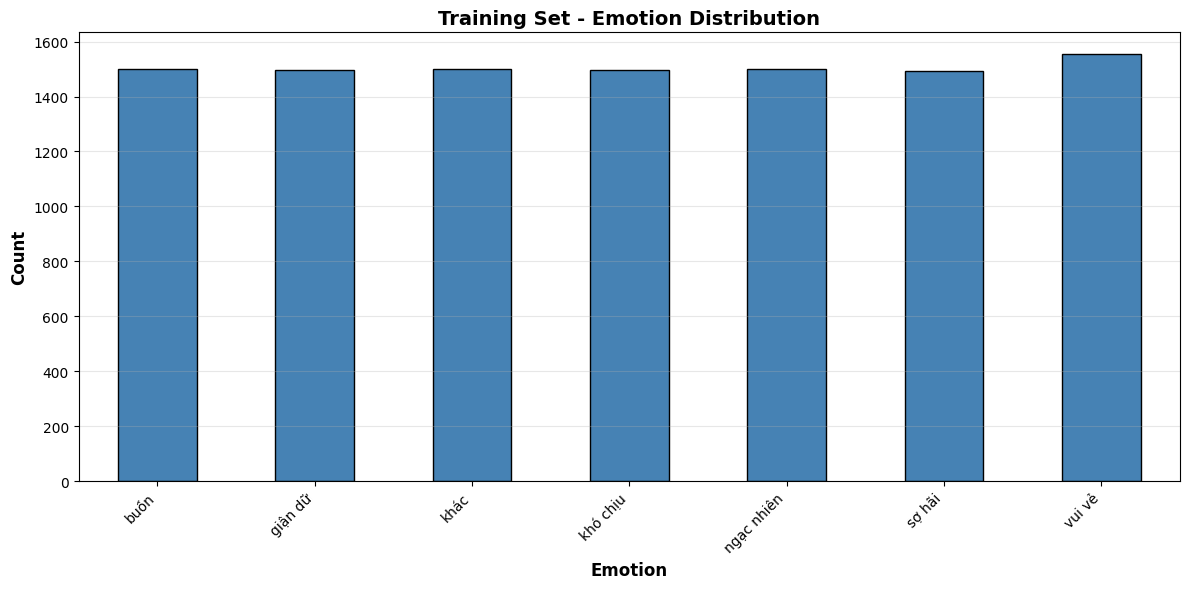


✓ Class distribution analyzed (7 emotions)


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze distribution
label_counts = train_df['label'].value_counts()
print("Emotion distribution (Training set):")
print(label_counts)
print(f"\nImbalance ratio: {label_counts.max() / label_counts.min():.1f}:1")

# Visualize
plt.figure(figsize=(12, 6))
label_counts.sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Emotion', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Training Set - Emotion Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Class distribution analyzed ({num_classes} emotions)")

## 7. Tokenize Data & Load Model


In [9]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np

# Convert string labels to integer IDs before creating datasets
train_df['label'] = train_df['label'].map(label2id)
val_df['label'] = val_df['label'].map(label2id)
test_df['label'] = test_df['label'].map(label2id)

# Convert to Dataset format
train_dataset = Dataset.from_pandas(train_df[['text', 'label']].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[['text', 'label']].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[['text', 'label']].reset_index(drop=True))

print(f"✓ Datasets converted to HuggingFace format")
print(f"✓ Labels converted from strings to integers")

# Load model and tokenizer
print(f"\nLoading model: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

print(f"✓ Model and tokenizer loaded")
print(f"✓ Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Tokenize
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

print(f"\n✓ Tokenized {len(train_tokenized)} training samples")
print(f"✓ Tokenized {len(val_tokenized)} validation samples")
print(f"✓ Tokenized {len(test_tokenized)} test samples")


✓ Datasets converted to HuggingFace format
✓ Labels converted from strings to integers

Loading model: vinai/phobert-base-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model and tokenizer loaded
✓ Number of parameters: 135,003,655


Map:   0%|          | 0/10541 [00:00<?, ? examples/s]

Map:   0%|          | 0/686 [00:00<?, ? examples/s]

Map:   0%|          | 0/963 [00:00<?, ? examples/s]


✓ Tokenized 10541 training samples
✓ Tokenized 686 validation samples
✓ Tokenized 963 test samples


## 8. Load Model and Setup Training


In [10]:
import torch
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# Device setup (GPU/CPU only, TPU removed)
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✓ Using device: cuda")
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    device = torch.device('cpu')
    print(f"✓ Using device: cpu")

# Load model
print(f"\nLoading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

print(f"✓ Model loaded with {num_classes} classes")
print(f"  Model size: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M parameters")

✓ Using device: cuda
  GPU: NVIDIA A100-SXM4-80GB
  Memory: 85.09 GB

Loading model: vinai/phobert-base-v2


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded with 7 classes
  Model size: 135.00M parameters


## 9. Define Metrics and Training Arguments


In [11]:
def compute_metrics(eval_pred):
    """Compute accuracy, precision, recall, and F1 scores."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Training arguments with Learning Rate Scheduler
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type='cosine',  # Options: 'linear', 'cosine', 'cosine_with_restarts', 'polynomial', 'constant', 'constant_with_warmup'
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="wandb",
    run_name=f"phobert-v2-seed-{RANDOM_SEEDS[0]}"
)

print("✓ Training arguments configured")
print(f"  Effective batch size: {PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  LR scheduler: {training_args.lr_scheduler_type}")
print(f"  Warmup ratio: {WARMUP_RATIO}")
print(f"  Mixed precision (FP16): {training_args.fp16}")
print(f"  Early stopping: enabled (patience=5, metric=f1)")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✓ Training arguments configured
  Effective batch size: 128
  Learning rate: 2e-05
  LR scheduler: SchedulerType.COSINE
  Warmup ratio: 0.1
  Mixed precision (FP16): True
  Early stopping: enabled (patience=5, metric=f1)


## 10. Train the Model


In [12]:
# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

print("🚀 Starting training...\n")
print("=" * 80)

# Train the model
trainer.train()

print("\n" + "=" * 80)
print("✅ Training completed!")

🚀 Starting training...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.935742,1.810870,0.346939,0.426275,0.346939,0.347073
2,1.387241,1.364153,0.508746,0.529455,0.508746,0.509233
3,1.094717,1.289268,0.521866,0.564992,0.521866,0.531018
4,0.787909,1.227929,0.553936,0.575870,0.553936,0.559561
5,0.644274,1.287691,0.558309,0.596139,0.558309,0.564955
6,0.559080,1.406588,0.537901,0.590760,0.537901,0.544744
7,0.457656,1.472185,0.536443,0.607117,0.536443,0.545909
8,0.380563,1.372067,0.561224,0.581781,0.561224,0.566286
9,0.321114,1.459466,0.564140,0.592209,0.564140,0.570213
10,0.256642,1.504980,0.553936,0.583540,0.553936,0.558953


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Training completed!


## 11. Save Model to Google Drive


In [13]:
import json
from datetime import datetime

# Create versioned model path with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_version = f"PhoBERT_v2_Advanced_Test_seed{RANDOM_SEEDS[0]}_{timestamp}"
MODEL_SAVE_PATH = f"/content/drive/MyDrive/thesis/{model_version}"

print("💾 Saving BEST model to Google Drive...")
print(f"📝 Model version: {model_version}")
print(f"🏆 Best seed: {RANDOM_SEEDS[0]}")

# Create directory if it doesn't exist
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Save model and tokenizer
trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

# Save label mappings
label_mappings = {
    'label2id': label2id,
    'id2label': id2label
}
with open(os.path.join(MODEL_SAVE_PATH, 'label_mappings.json'), 'w', encoding='utf-8') as f:
    json.dump(label_mappings, f, ensure_ascii=False, indent=2)

# Save model metadata
model_metadata = {
    "model_name": MODEL_NAME,
    "model_version": model_version,
    "timestamp": timestamp,
    "num_classes": num_classes,
    "emotions": labels,
    "training_params": {
        "batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "learning_rate": LEARNING_RATE,
        "num_epochs": NUM_EPOCHS,
        "max_length": MAX_LENGTH
    },
    "best_seed": RANDOM_SEEDS[0],
    "use_underthesea": USE_UNDERTHESEA_TOKENIZER,
    "test_set": "test_gen_final.csv"
}

with open(os.path.join(MODEL_SAVE_PATH, 'model_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(model_metadata, f, ensure_ascii=False, indent=2)

print(f"✓ Model saved successfully to: {MODEL_SAVE_PATH}")
print(f"  - Model weights")
print(f"  - Tokenizer")
print(f"  - Label mappings")
print(f"  - Model metadata")
print(f"\n📁 You can access this versioned model from your Google Drive anytime!")

💾 Saving BEST model to Google Drive...
📝 Model version: PhoBERT_v2_Advanced_Test_seed42_20260417_081054
🏆 Best seed: 42


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model saved successfully to: /content/drive/MyDrive/thesis/PhoBERT_v2_Advanced_Test_seed42_20260417_081054
  - Model weights
  - Tokenizer
  - Label mappings
  - Model metadata

📁 You can access this versioned model from your Google Drive anytime!


## 12. Evaluate on Test Set


Evaluating on test set...



📊 TEST SET RESULTS
Accuracy:  0.7072
Precision: 0.7214
Recall:    0.7072
F1 Score:  0.7104

📊 CLASSIFICATION REPORT - TEST SET

              precision    recall  f1-score   support

        buồn     0.7119    0.7241    0.7179       116
     giận dữ     0.8404    0.5985    0.6991       132
        khác     0.5693    0.6047    0.5865       129
    khó chịu     0.4878    0.6107    0.5424       131
  ngạc nhiên     0.8240    0.7863    0.8047       131
      sợ hãi     0.8507    0.8702    0.8604       131
      vui vẻ     0.7487    0.7409    0.7448       193

    accuracy                         0.7072       963
   macro avg     0.7190    0.7051    0.7080       963
weighted avg     0.7214    0.7072    0.7104       963



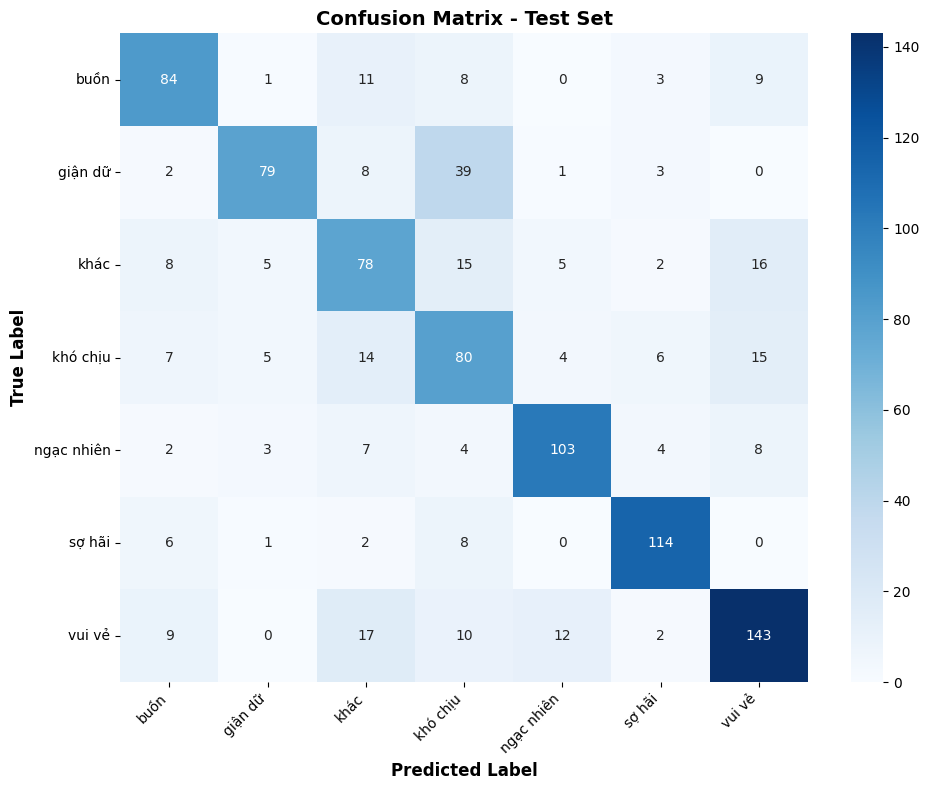


✅ Confusion matrix and classification report generated.



In [14]:
print("Evaluating on test set...\n")

# Get predictions
predictions = trainer.predict(test_tokenized)
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# Calculate metrics
test_accuracy = accuracy_score(true_labels, pred_labels)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    true_labels, pred_labels, average='weighted', zero_division=0
)

print(f"{'='*80}")
print("📊 TEST SET RESULTS")
print(f"{'='*80}")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"{'='*80}")

# Detailed classification report
print(f"\n{'='*80}")
print("📊 CLASSIFICATION REPORT - TEST SET")
print(f"{'='*80}\n")
print(classification_report(
    true_labels,
    pred_labels,
    target_names=[id2label[i] for i in range(num_classes)],
    digits=4
))

# Compute confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, pred_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[id2label[i] for i in range(num_classes)],
    yticklabels=[id2label[i] for i in range(num_classes)]
)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("✅ Confusion matrix and classification report generated.")
print(f"{'='*80}\n")

# Log to W&B
wandb.log({
    'test_accuracy': test_accuracy,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'test_f1': test_f1
})

## 14. Finish W&B Run


In [15]:
wandb.finish()
print("✅ W&B run finished")
print("\n🎉 Training and evaluation complete!")
# Automatically disconnect Colab after 3 minutes for resource management

import time
import os

def schedule_colab_disconnect(delay_seconds=180):
    print(f"\n⏳ Colab will disconnect in {delay_seconds//60} minutes...")
    time.sleep(delay_seconds)
    print("\n🚦 Disconnecting Colab runtime now.")
    os.kill(os.getpid(), 9)  # This will immediately interrupt and disconnect the session

# Start the scheduled disconnect (Colab only)
try:
    from google.colab import drive  # crude check for Colab
    import threading
    threading.Thread(target=schedule_colab_disconnect, args=(180,), daemon=True).start()
except ImportError:
    print("Not running in Google Colab: auto-disconnect skipped.")

eval/accuracy,▁▆▆▇█▇▇██▇██▇██▇███
eval/f1,▁▆▇▇█▇▇██▇█████▇███
eval/loss,█▃▂▁▂▃▄▃▄▄▅▅▆▆▆▇▇▇▇
eval/precision,▁▅▆▇█▇█▇▇▇▇▇██▇▇▇▇▇
eval/recall,▁▆▆▇█▇▇██▇██▇██▇███
eval/runtime,▃▃█▂▆▁▃▂▂▄▃▆▂▅▃▂▁▅▃
eval/samples_per_second,▆▆▁▇▃█▆▇▇▅▆▃▇▄▆▇█▄▅
eval/steps_per_second,▆▆▁▇▃█▆▇▇▅▆▃▇▄▆▇█▄▅
test/accuracy,▁
test/f1,▁
+15,...


✅ W&B run finished

🎉 Training and evaluation complete!

⏳ Colab will disconnect in 3 minutes...
